
# Bayesian model selection

An overview of Bayesian model selection combining gammapy with ultranest and arziv packages. 


## Context

For a general overview see:
- https://arviz-devs.github.io/EABM/Chapters/Model_comparison.html
- https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html

Here we are going to focus on the following questions:
- What are the comon information criterion used for model selection nowadays  ?
- how the parameter posterior is sensitive to the choice of prior ?
- how model comparison is sensitive to the choice of prior ?


## Proposed approach

In this example, we will perform a Bayesian analysis with multiple 1D
spectra of the Crab nebula data. Then we will discuss how to interpret the posterior
distributions, the sensitivity to prior of the different information criterion used for model selection, and how to define the priors.




## Setup

As usual, we’ll start with some setup …




In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
from gammapy.datasets import Datasets
from gammapy.datasets import SpectrumDatasetOnOff

from gammapy.modeling.models import (
    SkyModel,
    UniformPrior,
    LogUniformPrior,
    GaussianPrior,
)
import arviz as az

from gammapy.modeling.sampler import Sampler

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Loading the spectral datasets

Here we will load a few Crab 1D spectral data for which we will do a
fit.




In [2]:
path = "$GAMMAPY_DATA/joint-crab/spectra/hess/"

datasets = Datasets()
for id in ["23523", "23526", "23559", "23592"]:
    dataset = SpectrumDatasetOnOff.read(f"{path}pha_obs{id}.fits")
    datasets.append(dataset)

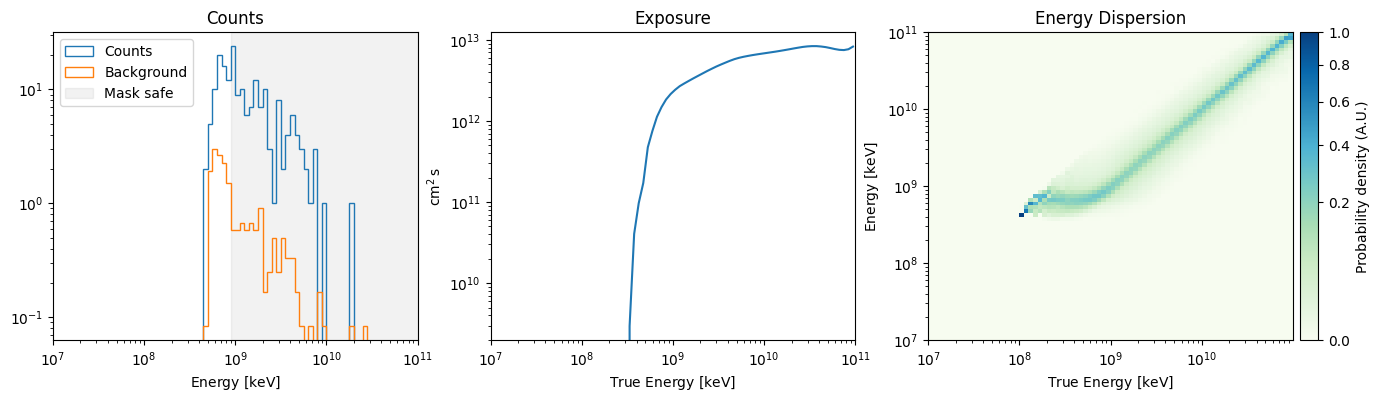

In [3]:
datasets[0].peek()

## Model definition

Now we want to define the spectral model that will be fitted to the
data.
The Crab spectra will be fitted here with as a powerlaw or a log parabola with prior of different strenght.
(names are qualitatives).


In [4]:
# create as set of alternative models with different spectral shape and prior strenght
from gammapy.modeling.models import create_crab_spectral_model, Models

alternative_models = {}
models_types = ["lp", "pl"]
# prior_types = ["uniformative"]
prior_types = ["uniformative", "magic-weak", "magic-strong"]

for model_type in models_types:
    for prior_type in prior_types:
        model_name = f"{model_type}({prior_type})"
        model = SkyModel.create(spectral_model=model_type, name=f"crab-{model_name}")
        model.spectral_model.reference.value = 1

        ref_model = create_crab_spectral_model("magic_lp")

        if model_type == "lp":
            if "uniformative" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-14, max=1e-8
                )
                model.spectral_model.alpha.prior = UniformPrior(min=0, max=10)
                model.spectral_model.beta.prior = UniformPrior(min=0, max=10)
            elif "weak" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-13, max=1e-9
                )
                model.spectral_model.alpha.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=2
                )
                model.spectral_model.beta.prior = UniformPrior(min=0, max=1)
            elif "strong" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-11, max=1e-10
                )
                model.spectral_model.alpha.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=0.1
                )
                model.spectral_model.beta.prior = GaussianPrior(
                    mu=ref_model.beta.value, sigma=0.1
                )
        elif model_type == "pl":
            if "uniformative" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-14, max=1e-8
                )
                model.spectral_model.index.prior = UniformPrior(min=0, max=10)
            elif "weak" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-13, max=1e-9
                )
                model.spectral_model.index.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=2
                )
            elif "strong" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-11, max=1e-10
                )
                model.spectral_model.index.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=0.1
                )
        alternative_models[model_name] = Models(model)

alternative_models

{'lp(uniformative)': <gammapy.modeling.models.core.Models at 0x137575dd0>,
 'lp(magic-weak)': <gammapy.modeling.models.core.Models at 0x137777110>,
 'lp(magic-strong)': <gammapy.modeling.models.core.Models at 0x1377d0350>,
 'pl(uniformative)': <gammapy.modeling.models.core.Models at 0x1377d02d0>,
 'pl(magic-weak)': <gammapy.modeling.models.core.Models at 0x137782d90>,
 'pl(magic-strong)': <gammapy.modeling.models.core.Models at 0x1377c0dd0>}

## Defining the sampler and options


In [5]:
sampler_opts = {
    "live_points": 500,
    "frac_remain": 0.1,
    "log_dir": None,
}

sampler = Sampler(backend="ultranest", sampler_opts=sampler_opts)

## Defining the model selection manager

We define a `BayesianModelSelection` that will run the inference

In [6]:
from gammapy.modeling.selection import BayesianModelSelection

bms = BayesianModelSelection(
    sampler, prosterior_reduction_factor=4, n_prior_samples=1000
)

Next we can run the sampler on a given datasets for a set of alternative_models.
No other options are accepted in the run method.

In [7]:
%%capture 
bms_results = bms.run(datasets, alternative_models)

## Exploring the results

The sampler has finished to evaluate all models. Let's start by looking at the results for one.

In [8]:
inference_result = bms_results["lp(uniformative)"]


### Parameters values

Within a Bayesian analysis, the concept of best-fit has to be viewed
differently from what is done in a gradient descent fit.

The output of the Bayesian analysis is the posterior distribution and
there is no “best-fit” output.
One has to define, based on the posteriors, what we want to consider
as “best-fit” and several options are possible:
- mean
- median
- mode
- maximum likelihood value
 
By default the mean values are assigned to the model paremeter values

In [9]:
inference_result.parameters_table()

parameter,mean,median,mode,value at max ln(L)
str9,float64,float64,float64,float64
amplitude,4.457867651097026e-11,4.457995966851757e-11,4.462038724380425e-11,4.466598768529042e-11
alpha,2.3252845068531,2.334829507130703,2.358125596819578,2.3394694763739725
beta,0.2129046084255064,0.20757738816525145,0.20130764993114272,0.19748267066206412


We can visualize the distributions with `plot_posterior` function of arviz:

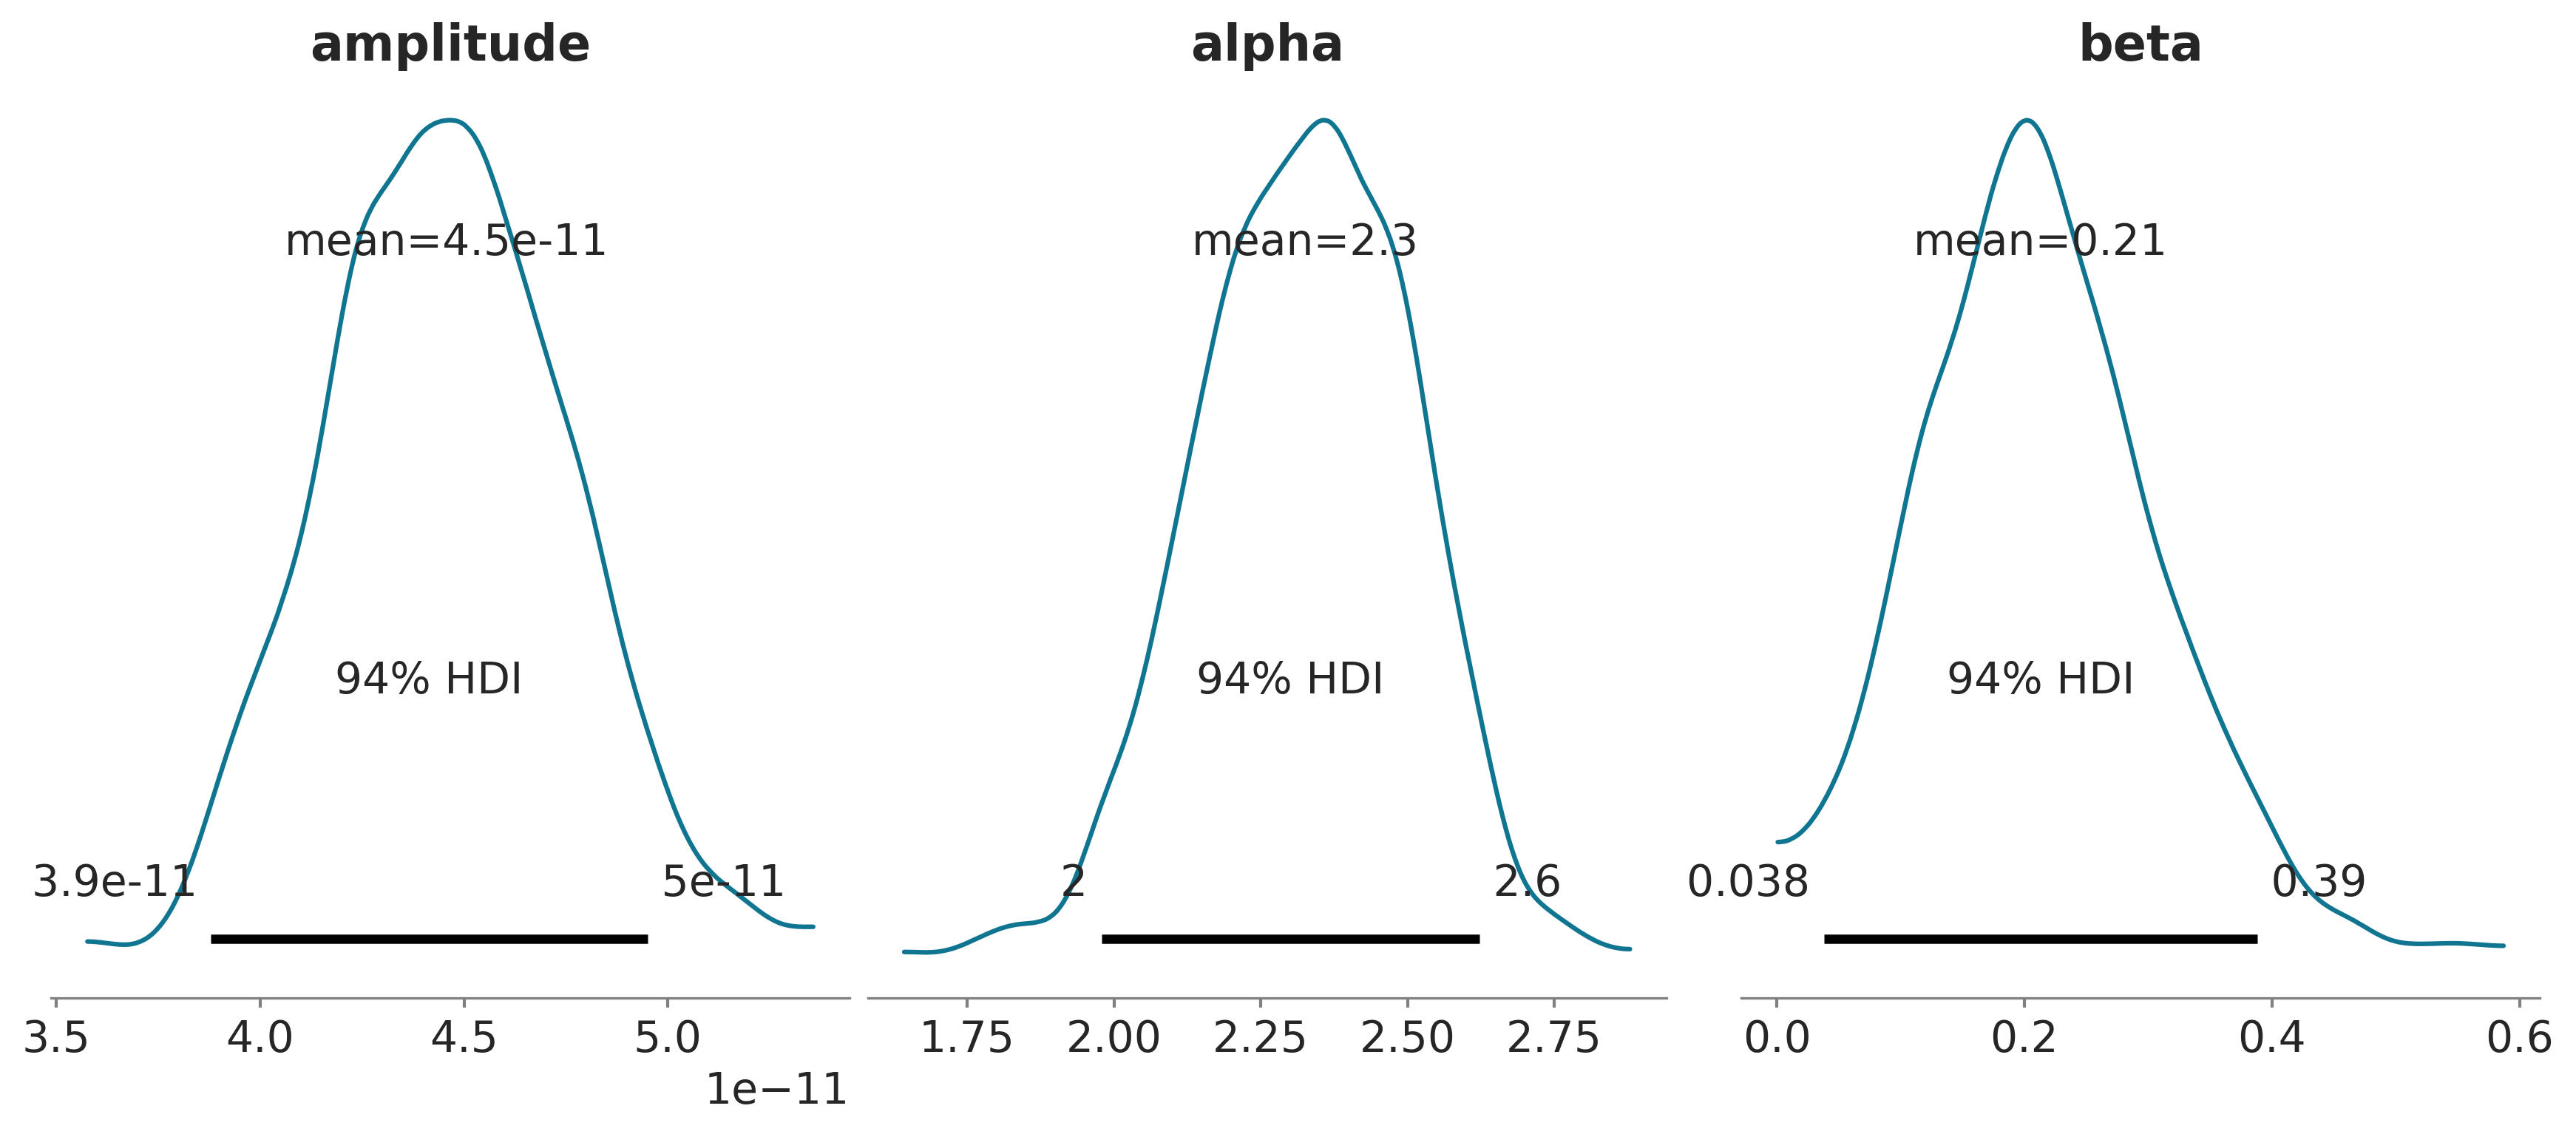

In [10]:
az.style.use("arviz-doc")
axes = az.plot_posterior(
    inference_result.idata,
    figsize=(11.5, 5),
)

fig = axes.flatten()[0].get_figure()

plt.show()

or the make a corner plot 

/Users/qremy/anaconda3/envs/gpy-dev/lib/python3.11/site-packages/arviz/plots/pairplot.py:229: UserWarning: Divergences data not found, plotting without divergences. Make sure the sample method provides divergences data and that it is present in the `diverging` field of `sample_stats` or `sample_stats_prior` or set divergences=False
  warnings.warn(


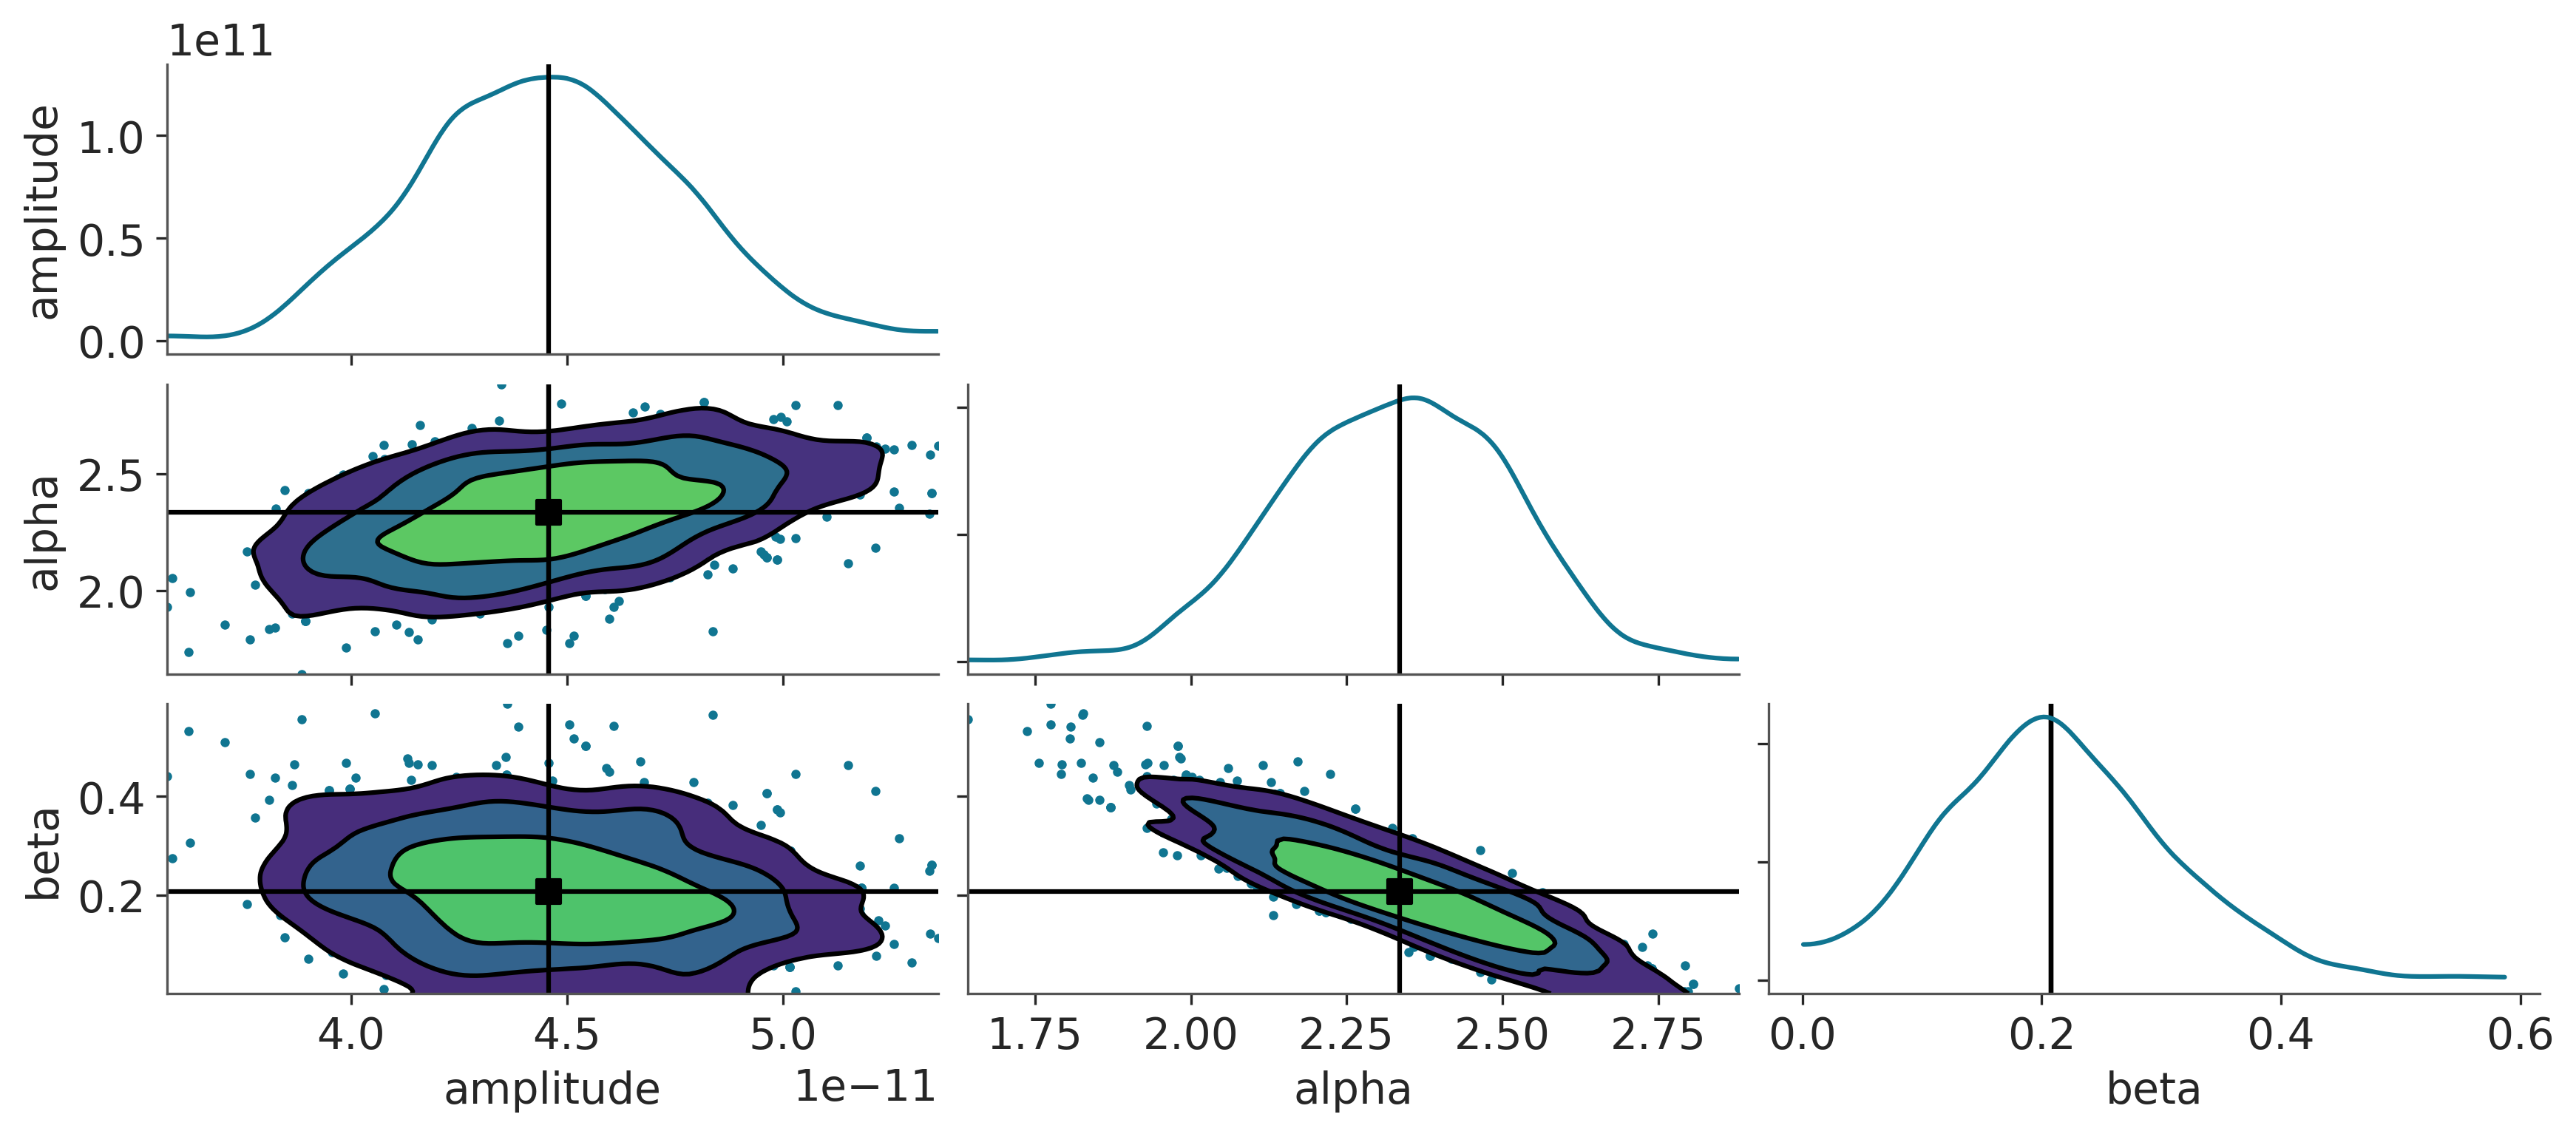

In [11]:
ax = az.plot_pair(
    inference_result.idata,
    kind=["scatter", "kde"],
    kde_kwargs={"fill_last": False},
    marginals=True,
    colorbar=True,
    divergences=True,
    point_estimate="median",
    figsize=(11.5, 5),
)

### Information criterions
#### Bayes Factor

Bayes factor can be used for model comparison of nested models, it increases if the model difference is more significative. \
Here we can see how much we gained between the prior and the posterior.

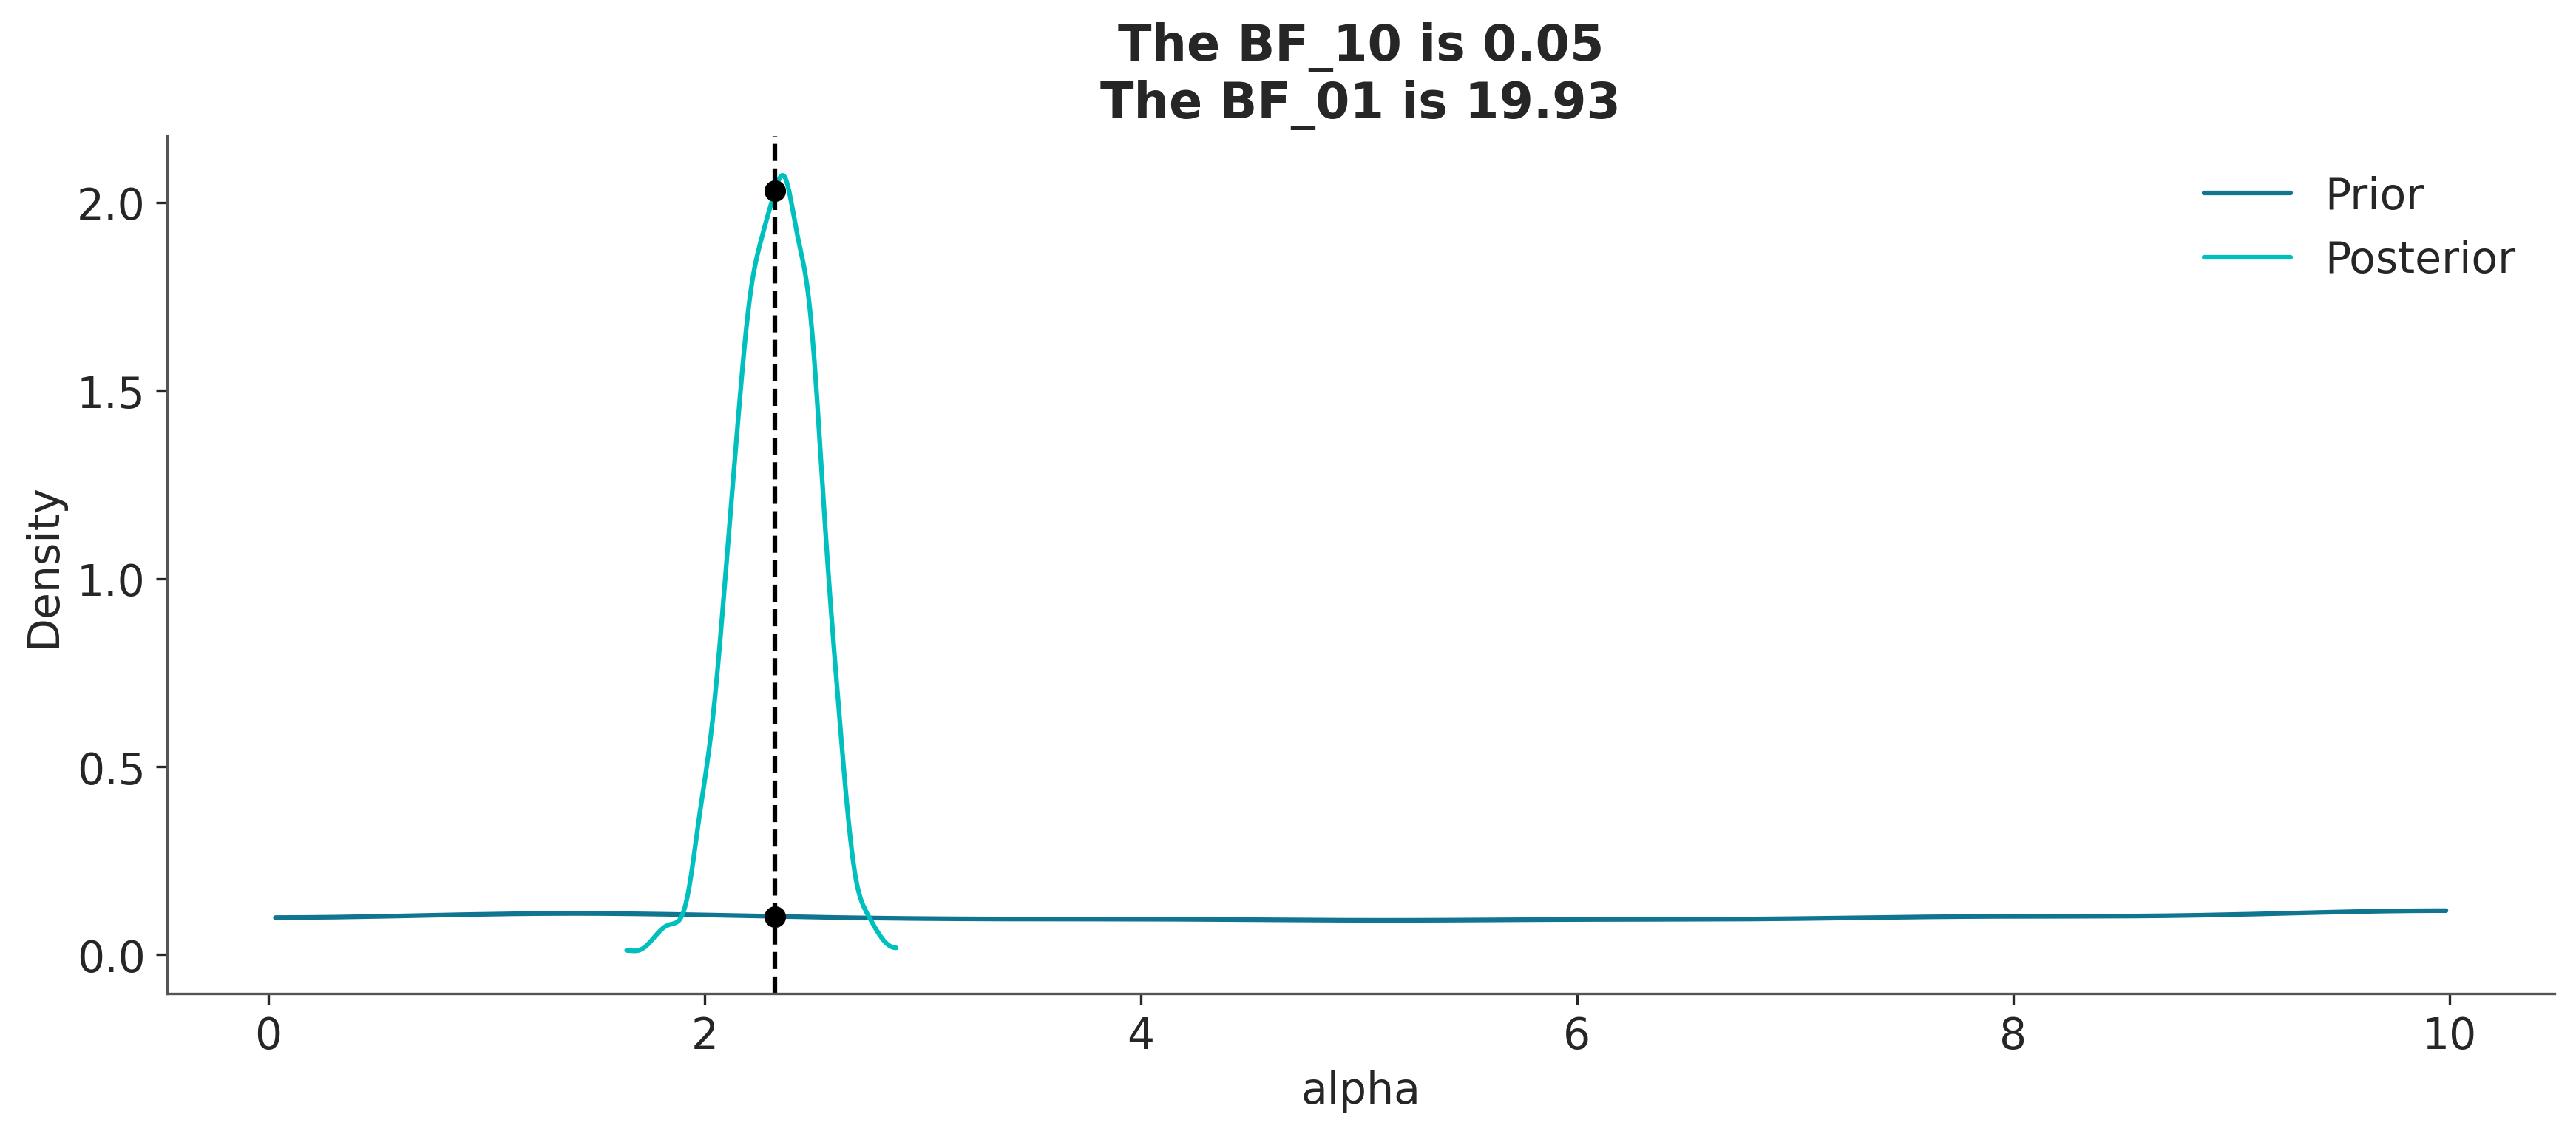

In [12]:
az.plot_bf(
    inference_result.idata,
    var_name="alpha",
    ref_val=inference_result.models.parameters["alpha"].value,
)
plt.show()

#### ELPD : expected log-predictive density

The ELPD is a more Bayesian way to measure goodness of fit that the term used in AIC, but we are still missing one element, the penalization term, which is added in the following statistics.

Asymptotically tends to AIC.


#### WAIC widely applicable information criterion

The Widely applicable information criterion (WAIC) uses the ELPD plus a penalization term [(Watanabe 2013)](https://arviz-devs.github.io/EABM/Chapters/References.html#ref-watanabe_2013).

In [13]:
inference_result.elpd_waic

Computed from 1919 posterior samples and 168 observations log-likelihood matrix.

              Estimate       SE
deviance_waic   159.01    18.52
p_waic            3.77        -

There has been a warning during the calculation. Please check the results.

#### PSIS-LOO-CV : Pareto-smoothed importance sampling leave-one-out cross-validation



Another way to add penalization on ELPD penalization is cross-validation.

One round of cross-validation involves partitioning a sample of data into complementary subsets, performing the analysis on one subset (called the training set), and validating the analysis on the other subset (called the validation set or testing set).
Leave-p-out cross-validation involves using p observations as the validation set and the remaining observations as the training set.
Leave-one-out cross-validation (LOOCV) is a particular case of leave-p-out cross-validation with p = 1.

One downside of cross-validation is that it is computationally expensive. We need to fit the model 
 times, and if we have a large dataset, this can be very expensive. But lucky us, by being Bayesian we can approximately compute LOO-CV in a very fast way unsing importance sampling. The method used here is the Pareto-Smooth Importance Sampling Leave-One-Out Cross Validation [(Vehtari, Gelman, and Gabry 2017; Yao et al. 2018)](https://arviz-devs.github.io/EABM/Chapters/References.html#ref-vehtari_2017), which is abbreviated as PSIS-LOO-CV


In [14]:
elpd_loo = inference_result.elpd_loo
elpd_loo

Computed from 1919 posterior samples and 168 observations log-likelihood matrix.

             Estimate       SE
deviance_loo   159.04    18.52
p_loo            3.79        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      168  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

The Pareto k diagnostic tell us if the approximation used to compute LOO is valid. In general ideally it should be lower than 0.7 in every pixel.

The p_loo/p_waic give us an estimate of the effective number of parameters. 

LOO should be more robust than WAIC.

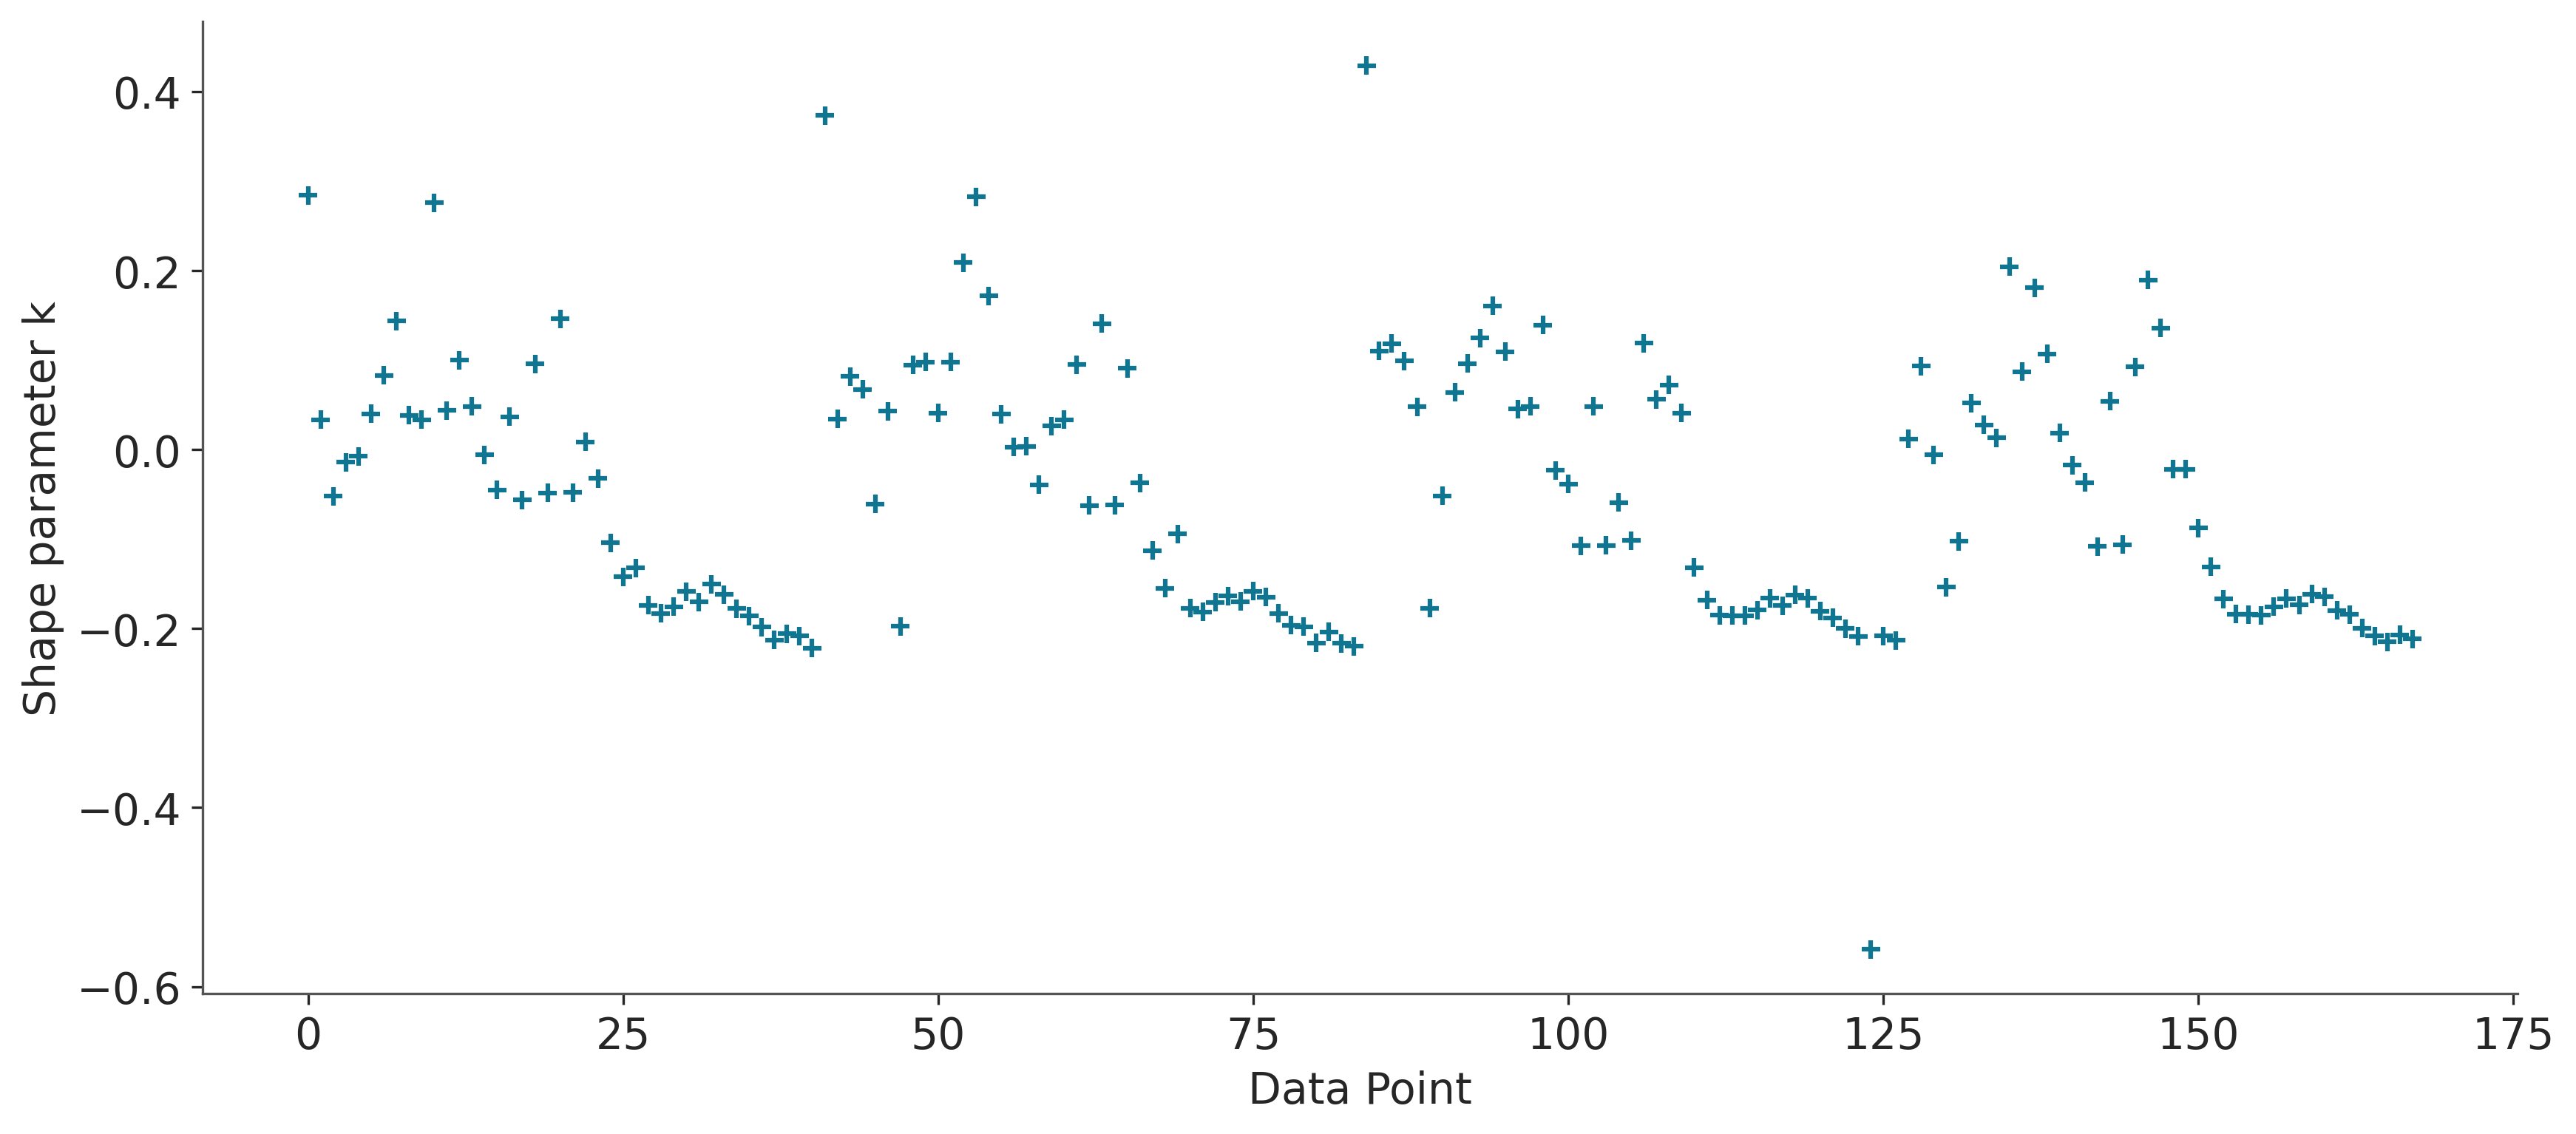

In [15]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_khat(elpd_loo)
plt.show()

## Model comparison
Wewe can have a look at the statistics summary table for all models 

In [16]:
# lower is better
bms_results.stats_table()

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof,logz error,elpd error (waic),elpd error (loo),good Pareto k fraction
str16,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
lp(uniformative),177.206,152.047,158.047,159.009,159.041,3.000,3.772,3.788,0.468,18.518,18.522,1.000
lp(magic-weak),169.585,152.054,158.054,159.065,159.131,3.000,3.794,3.827,0.416,18.552,18.563,1.000
lp(magic-strong),160.897,152.044,158.044,157.095,157.131,3.000,2.558,2.576,0.371,17.946,17.951,1.000
pl(uniformative),174.279,156.994,160.994,161.568,161.597,2.000,2.532,2.547,0.567,17.189,17.192,1.000
pl(magic-weak),172.356,156.993,160.993,161.543,161.575,2.000,2.532,2.548,0.393,17.195,17.199,1.000
pl(magic-strong),167.351,156.993,160.993,162.070,162.094,2.000,2.210,2.222,0.280,17.037,17.040,1.000


Now let's can compare the different models to a reference model. \
So H0 will be the reference model taken as the powerl-law with uniformation prior `pl(uniformative)` and H1 each of the other models.

In [17]:
# lower => H0 is better
stats_difference_table = bms_results.stats_difference_table(
    reference_models_name="pl(uniformative)"
)
display(stats_difference_table)

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof
str43,float64,float64,float64,float64,float64,int64,float64,float64
H0: pl(uniformative) - H1: lp(uniformative),-2.927,4.947,2.947,2.559,2.555,-1.000,-1.239,-1.241
H0: pl(uniformative) - H1: lp(magic-weak),4.694,4.940,2.940,2.504,2.465,-1.000,-1.261,-1.281
H0: pl(uniformative) - H1: lp(magic-strong),13.382,4.950,2.950,4.473,4.465,-1.000,-0.025,-0.029
H0: pl(uniformative) - H1: pl(magic-weak),1.923,0.001,0.001,0.026,0.021,0.000,0.001,-0.002
H0: pl(uniformative) - H1: pl(magic-strong),6.928,0.001,0.001,-0.501,-0.497,0.000,0.323,0.325


In [18]:
# lower => H0 is better
stats_difference_table = bms_results.stats_difference_table(
    reference_models_name="pl(magic-strong)"
)
display(stats_difference_table)

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof
str43,float64,float64,float64,float64,float64,int64,float64,float64
H0: pl(magic-strong) - H1: lp(uniformative),-9.856,4.945,2.945,3.061,3.053,-1.000,-1.562,-1.566
H0: pl(magic-strong) - H1: lp(magic-weak),-2.234,4.939,2.939,3.005,2.962,-1.000,-1.584,-1.605
H0: pl(magic-strong) - H1: lp(magic-strong),6.453,4.949,2.949,4.974,4.963,-1.000,-0.348,-0.354
H0: pl(magic-strong) - H1: pl(uniformative),-6.928,-0.001,-0.001,0.501,0.497,0.000,-0.323,-0.325
H0: pl(magic-strong) - H1: pl(magic-weak),-5.005,-0.000,-0.000,0.527,0.518,0.000,-0.322,-0.326


As our simple test models are nested we can use Wilks theorem to scale ts=-2logl into significance in sigma

In [19]:
from gammapy.stats.utils import ts_to_sigma

ts = stats_difference_table["-2logl"][0]
dof = stats_difference_table["dof"][0]
sigma = ts_to_sigma(ts, np.abs(dof))
print("LP is favored at", sigma, "sigma")

LP is favored at 2.223812170751096 sigma


This tell us that the log-parabola is prefered over a power-law but not very significantly. \
Similarly AIC difference of 3 tell us than the models are almost equivalent to describe this dataset. \
We have the same conclusion from the difference in elpd which is small. In the next table we can see it's also small compared to the standard error on the elpd diffence, which is plotted in cyan in the comparision plot below.

The logz is more affected by the choice of prior, while it gives the same comclusions for a strong prior (2nd table, 5th row), it gives the opposite conclusion for the uniformative prior (1st table 1st row) as it penalize much more the models with more degree of freedom, this effect is amplified the weaker the prior is (because in that case the logz intergrate over a larger "irrelevant" parameter space). We see also that using logz to compare models with different prior strenght might reflect more the prior relative strengh than actual differences between the models.

As our statistics come with errors more robust comparisons can be done with the methods implemented in `arziv.compare` that we can call from our results object:

In [20]:
az_comparison = bms_results.compare(method="BB-pseudo-BMA")
az_comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
lp(magic-strong),0,157.131239,2.575688,0.000000,0.385260,17.568038,0.000000,False,deviance
lp(uniformative),1,159.041157,3.787722,1.909918,0.186635,18.173036,1.903303,False,deviance
lp(magic-weak),2,159.131477,3.827227,2.000238,0.178254,18.219219,1.887839,False,deviance
pl(magic-weak),3,161.575437,2.548231,4.444198,0.084417,16.665414,3.326508,False,deviance
pl(uniformative),4,161.596521,2.546562,4.465282,0.082472,16.661435,3.316848,False,deviance
pl(magic-strong),5,162.093855,2.221899,4.962616,0.082961,16.518988,3.735516,False,deviance


The weight can be loosely interpreted as the probability of each model (among the compared model) given the data.
The dSE is the standard error of the difference in ELPD between each model and the top-ranked model (plotted in cyan below). By default the uncertainty and the weights are computed using Bayesian bootstrap (while arziv defalut is "stacking" which gives very different results ?).

<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

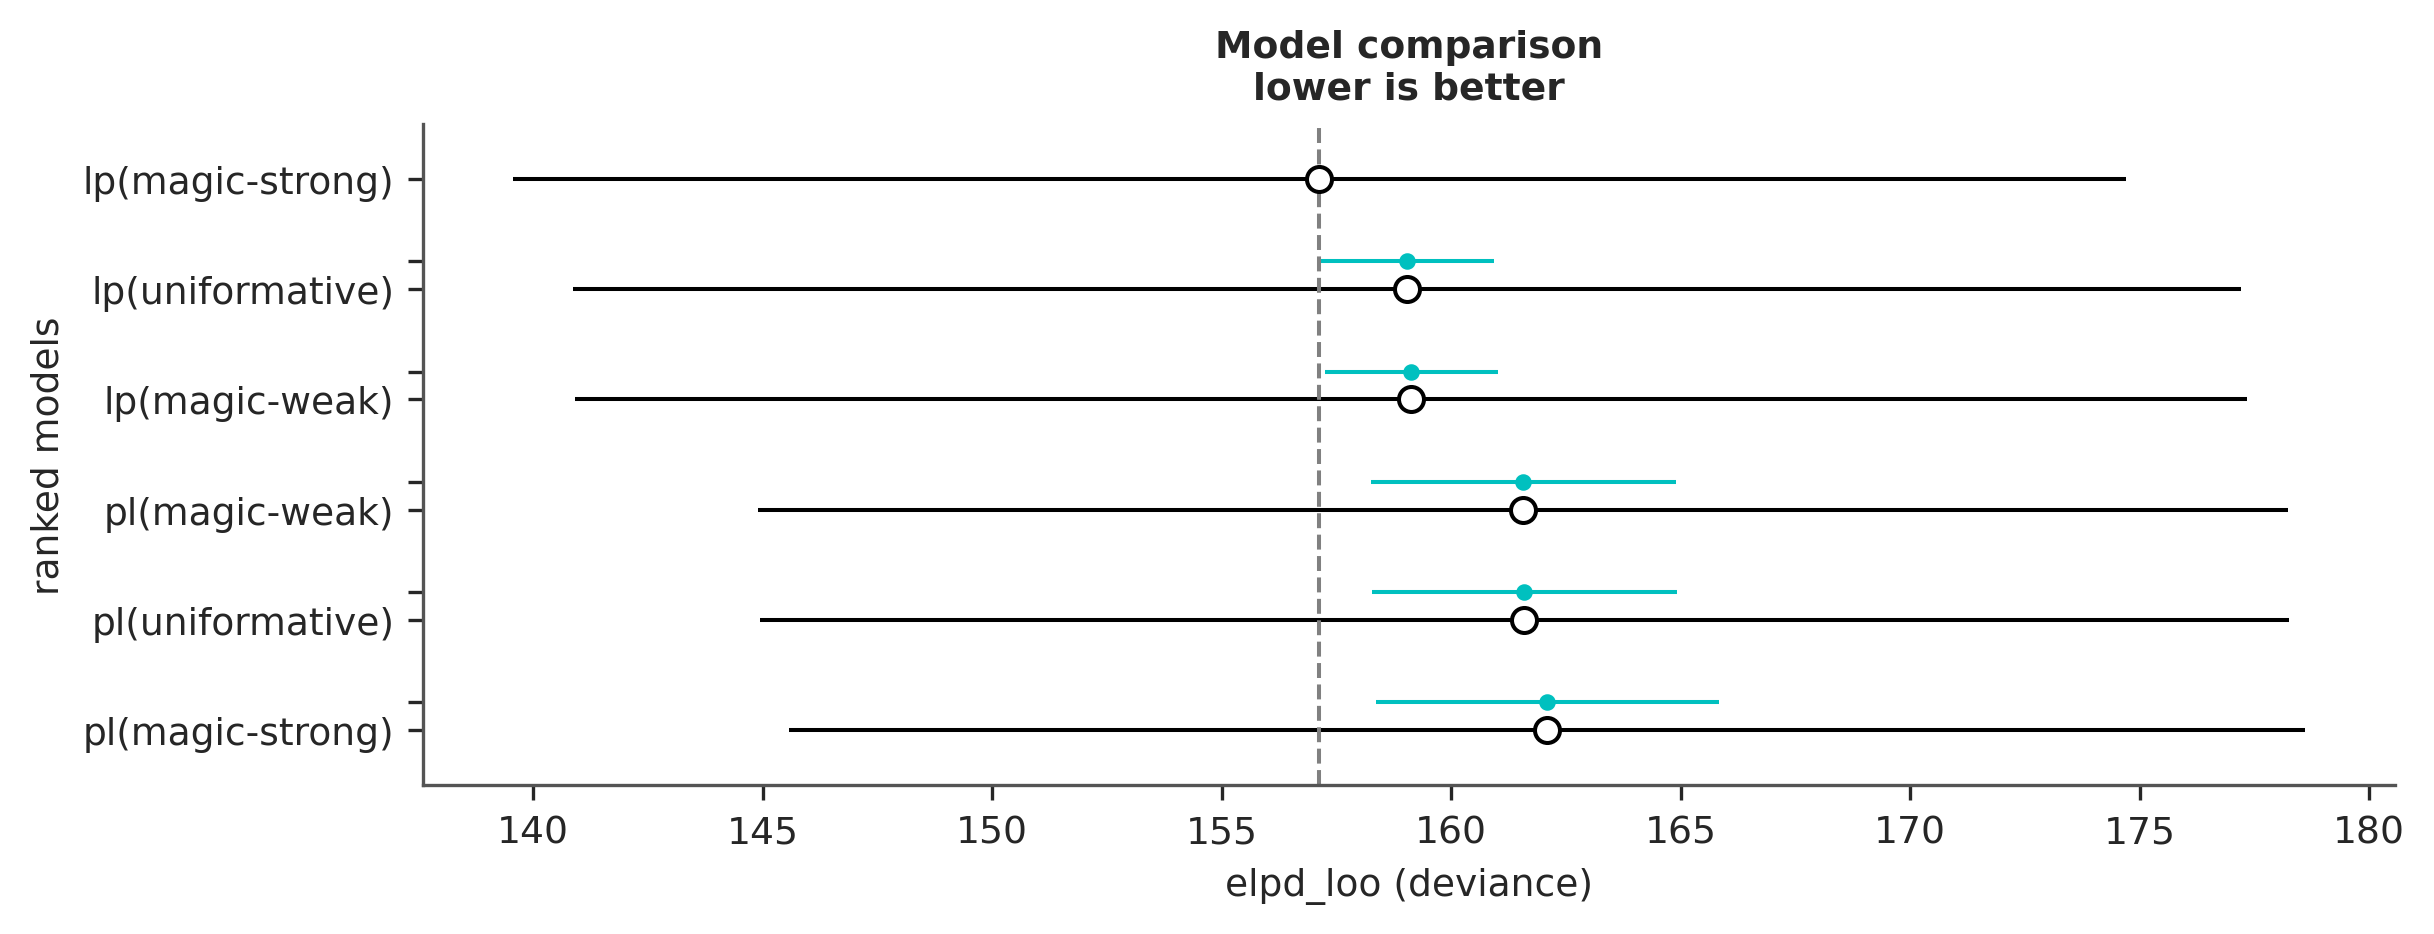

In [21]:
az.plot_compare(
    az_comparison,
    figsize=(8, 3),
    plot_ic_diff=True,
    plot_kwargs={"marker_dse": ".", "color_dse": "C1"},
)

### Prior and likelihood sensitivity diagnostics

`psens` function compute power-scaling sensitivity diagnostic.
If power-scales the prior or likelihood and calculates how much the posterior is affected.

Higher values returned indicate greater sensitivity. Prior sensitivity above 0.05 indicates informative prior**. Likelihood sensitivity below 0.05 indicates weak or noninformative likelihood.

The result can also be visualized with `psense_summary` function from `arviz_stats` (which is part of `arziv["preview"]` package)
that is attavhed to our result object as `prior_sensitivity_table`

In [22]:
bms_results["lp(uniformative)"].prior_sensitivity_table()

component,prior,likelihood,diagnosis
label,,,
amplitude,0.011,0.088,✓
alpha,0.005,0.111,✓
beta,0.003,0.150,✓


In [23]:
bms_results["lp(magic-strong)"].prior_sensitivity_table()

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


component,prior,likelihood,diagnosis
label,,,
amplitude,0.017,0.092,✓
alpha,0.121,0.061,potential prior-data conflict
beta,0.119,0.055,potential prior-data conflict


In [24]:
# bms_results.prior_sensitivity_table() #this will display all the models names and the prior_sensitivity_table

### How to measure the strengh of a prior ?

https://arviz-devs.github.io/EABM/Chapters/Prior_elicitation.html#priors-and-entropy

The entropy is a property of probability distributions the same way the mean or variance are, actually it’s the expected value of the negative log probability of the distribution. We can think of entropy as a measure of the information or uncertainty of a distribution has. Loosely speaking the entropy of a distribution is high when the distribution is spread out and low when the distribution is concentrated. 

In [25]:
print(
    "pl(uniformative), index:",
    bms_results["pl(uniformative)"].priors["index"].entropy(),
)
print(
    "pl(magic-strong), index:",
    bms_results["pl(magic-strong)"].priors["index"].entropy(),
)

pl(uniformative), index: 2.302585092994046
pl(magic-strong), index: -0.8836465597893728


### How to define good prior ?

In the context of prior elicitation maximum entropy can be a guiding principle to pick priors. According to this principle we should choose the prior that maximizes the entropy, subject to known constraints of the prior (Jaynes 2003). This is a way to choose a prior that is as vague as possible, given the information we have.

So how can we build a weakly informative prior for our gamma-ray sources ? \
It could be based on know sources parameter distributions taken from a large set of catalogues.

In [26]:
from gammapy.catalog import CATALOG_REGISTRY

fgl4 = CATALOG_REGISTRY.get_cls("4fgl")()
fgl4 = fgl4.table

Let's filter the catalogue to keep sources with assocations matching one of Galactic source populations

In [27]:
selected_classes = ["PWN", "SNR", "SPP", "SFR", "PSR", "MSP", "BIN", "HMB", "LMB"]
selected_classes += [s.lower() for s in selected_classes]
selection_mask = np.array(
    [str(class1).strip() in selected_classes for class1 in fgl4["CLASS1"]]
)
fgl4_filtered = fgl4[selection_mask]

We load few other catalogues

In [28]:
hgps = CATALOG_REGISTRY.get_cls("hgps")().table
lhaaso1 = CATALOG_REGISTRY.get_cls("1LHAASO")().table
hwc3 = CATALOG_REGISTRY.get_cls("3hwc")().table

and create a Gaussian prior with the same mean and twice the standard deviation of the distribution from the catalogues.

In [29]:
from gammapy.modeling.models import Model
from gammapy.modeling.selection.inference_data import generate_prior_samples

indexes = np.concatenate(
    (
        fgl4_filtered["PL_Index"].data,
        hgps["Index_Spec_PL"].data,
        lhaaso1["gamma"].data,
        -hwc3["spec0_index"].data,
    )
)
indexes = indexes.data[np.isfinite(indexes)]

spectral_model = Model.create("pl", model_type="spectral")
n_sigma = 2  # could increase for a weaker prior
spectral_model.index.prior = GaussianPrior(
    mu=indexes.mean(), sigma=n_sigma * indexes.std()
)
index_samples = generate_prior_samples([spectral_model.index]).flatten()

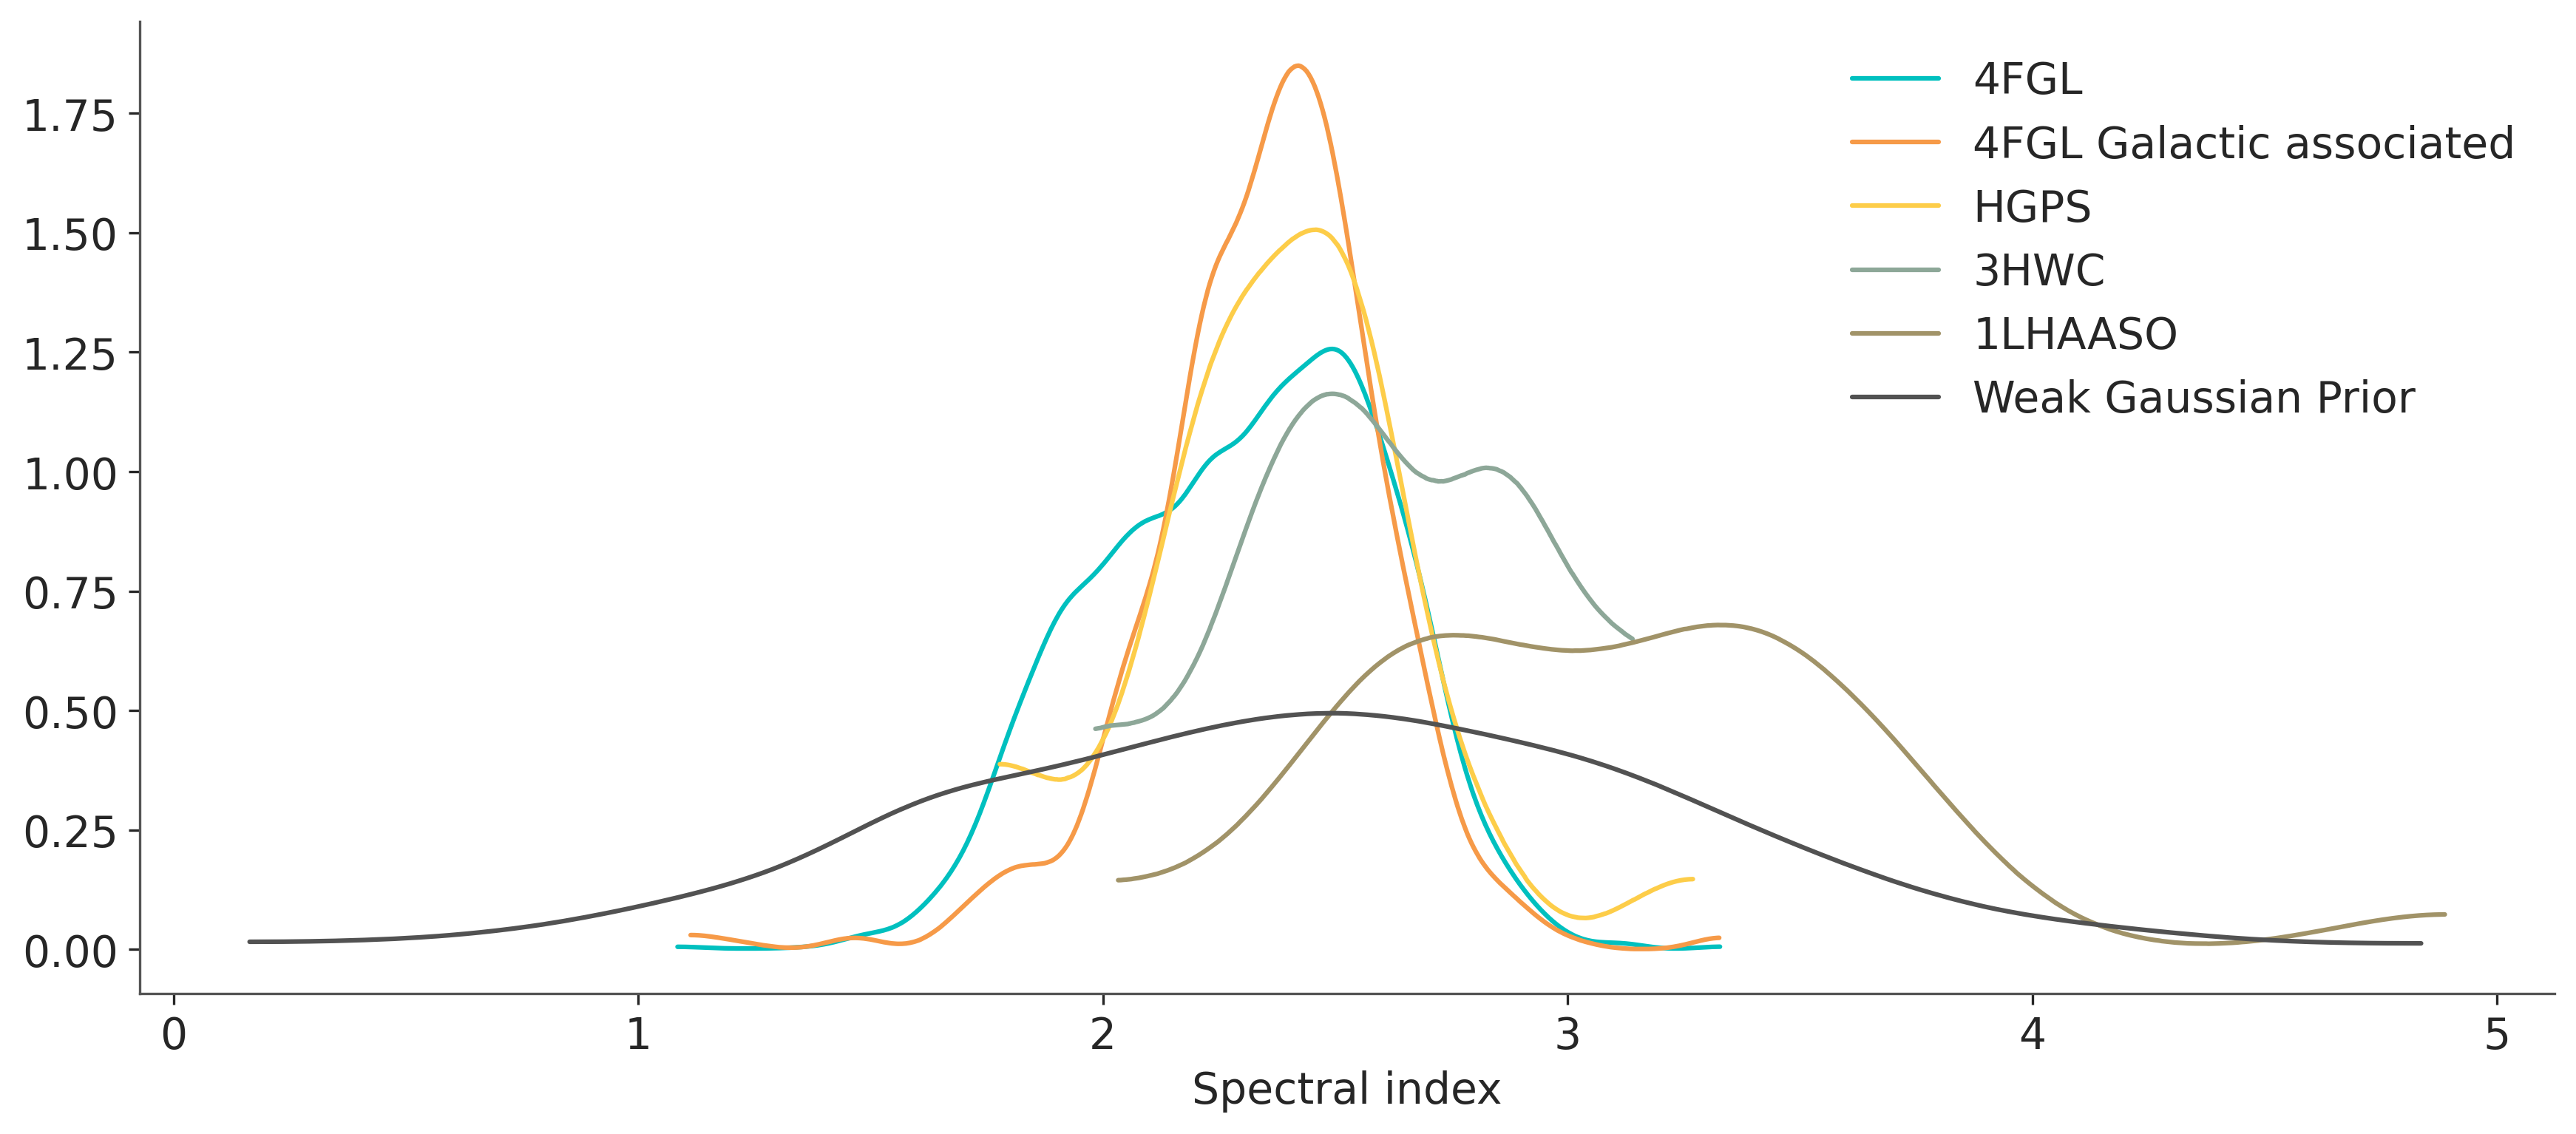

In [30]:
fig, ax = plt.subplots(1, 1)
az.plot_dist(fgl4["PL_Index"].astype(float), color="C1", label="4FGL")
az.plot_dist(
    fgl4_filtered["PL_Index"].astype(float),
    color="C2",
    label="4FGL Galactic associated",
)
az.plot_dist(hgps["Index_Spec_PL"].astype(float), color="C3", label="HGPS")
az.plot_dist(-hwc3["spec0_index"].astype(float), color="C4", label="3HWC")
az.plot_dist(lhaaso1["gamma"].astype(float), color="C5", label="1LHAASO")
az.plot_dist(index_samples, color="C6", label="Weak Gaussian Prior")
ax.set_xlabel("Spectral index")

plt.show()